In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful.")

Imports successful.


In [8]:
PROJECT_ROOT = Path.cwd().parent

In [9]:
# Find the Market Risk project root

current_path = Path.cwd()

possible_roots = [
    current_path,
    current_path.parent,
    current_path.parent.parent,
]

PROJECT_ROOT = None

for path in possible_roots:
    if (
        (path / "data").exists()
        and (path / "src").exists()
        and (path / "notebooks").exists()
    ):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the Market Risk project root."
    )

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk


In [10]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk.garch import (
    run_garch_analysis,
    calculate_historical_var,
)

print("GARCH module imported successfully.")

GARCH module imported successfully.


In [11]:
PORTFOLIO_DIR = PROJECT_ROOT / "data" / "portfolio"

portfolio_file = PORTFOLIO_DIR / "portfolio_daily.csv"

print("Portfolio file:")
print(portfolio_file)

print("\nExists:", portfolio_file.exists())

Portfolio file:
c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\portfolio\portfolio_daily.csv

Exists: True


In [12]:
portfolio_df = pd.read_csv(
    portfolio_file
)

print("portfolio_df created successfully.")
print()
print("Shape:", portfolio_df.shape)

portfolio_df created successfully.

Shape: (1652, 4)


In [13]:
portfolio_df.columns.tolist()

['Date', 'Portfolio Return', 'Portfolio P&L', 'Portfolio Value']

In [14]:
print(portfolio_df.head())

         Date  Portfolio Return  Portfolio P&L  Portfolio Value
0  2020-01-03         -0.009045   -9045.251511     9.909547e+05
1  2020-01-06          0.009246    9162.094279     1.000117e+06
2  2020-01-07         -0.000913    -913.191138     9.992037e+05
3  2020-01-08          0.009735    9727.329350     1.008931e+06
4  2020-01-09          0.009290    9372.541018     1.018304e+06


In [17]:
print(portfolio_df.columns.tolist())

['Date', 'Portfolio Return', 'Portfolio P&L', 'Portfolio Value']


In [21]:
return_column = "Portfolio Return"

if return_column not in portfolio_df.columns:
    raise ValueError(
        f"Column '{return_column}' not found.\n"
        f"Available columns: {portfolio_df.columns.tolist()}"
    )

print(f"Using return column: {return_column}")

Using return column: Portfolio Return


In [22]:
returns = pd.to_numeric(
    portfolio_df["Portfolio Return"],
    errors="coerce",
)

returns = returns.replace(
    [np.inf, -np.inf],
    np.nan,
).dropna()

returns.name = "portfolio_return"

print("Number of observations:", len(returns))
print()
print(returns.head())

Number of observations: 1652

0   -0.009045
1    0.009246
2   -0.000913
3    0.009735
4    0.009290
Name: portfolio_return, dtype: float64


In [23]:
dates = pd.to_datetime(
    portfolio_df["Date"],
    errors="coerce",
)

returns.index = dates

returns = returns[
    returns.index.notna()
]

returns = returns.sort_index()

print(returns.head())
print()
print("Start:", returns.index.min())
print("End:", returns.index.max())
print("Observations:", len(returns))

Date
2020-01-03   -0.009045
2020-01-06    0.009246
2020-01-07   -0.000913
2020-01-08    0.009735
2020-01-09    0.009290
Name: portfolio_return, dtype: float64

Start: 2020-01-03 00:00:00
End: 2026-07-31 00:00:00
Observations: 1652


In [24]:
print(returns.describe())

count    1652.000000
mean        0.000975
std         0.017080
min        -0.148607
25%        -0.006551
50%         0.001594
75%         0.009923
max         0.118835
Name: portfolio_return, dtype: float64


In [25]:
garch_result = run_garch_analysis(
    returns
)

print("GARCH(1,1) fitted successfully.")

GARCH(1,1) fitted successfully.


In [26]:
print(
    garch_result.model.summary()
)

                     Constant Mean - GARCH Model Results                      
Dep. Variable:       portfolio_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2957.17
Distribution:                  Normal   AIC:                           5922.34
Method:            Maximum Likelihood   BIC:                           5943.98
                                        No. Observations:                 1652
Date:                Thu, Oct 01 2026   Df Residuals:                     1651
Time:                        17:28:30   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1261  3.415e-02      3.691  2.231e-04 [5.913e-0

In [27]:
print(
    "Forecast volatility:",
    f"{garch_result.forecast_volatility:.6%}"
)

Forecast volatility: 1.472983%


In [28]:
print(
    "90% GARCH VaR:",
    f"{garch_result.var_90:.6%}"
)

print(
    "95% GARCH VaR:",
    f"{garch_result.var_95:.6%}"
)

print(
    "99% GARCH VaR:",
    f"{garch_result.var_99:.6%}"
)

90% GARCH VaR: 1.830181%
95% GARCH VaR: 2.419379%
99% GARCH VaR: 4.004460%


In [29]:
return_column = "Portfolio Return"

In [30]:
print(returns.describe())

count    1652.000000
mean        0.000975
std         0.017080
min        -0.148607
25%        -0.006551
50%         0.001594
75%         0.009923
max         0.118835
Name: portfolio_return, dtype: float64


In [31]:
garch_result = run_garch_analysis(
    returns
)

print("GARCH(1,1) fitted successfully.")

GARCH(1,1) fitted successfully.


In [32]:
print(garch_result.model.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:       portfolio_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2957.17
Distribution:                  Normal   AIC:                           5922.34
Method:            Maximum Likelihood   BIC:                           5943.98
                                        No. Observations:                 1652
Date:                Thu, Oct 01 2026   Df Residuals:                     1651
Time:                        17:31:52   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1261  3.415e-02      3.691  2.231e-04 [5.913e-0

In [33]:
conditional_volatility = (
    garch_result.conditional_volatility
)

print(conditional_volatility.head())
print()
print(conditional_volatility.describe())

Date
2020-01-03    0.020835
2020-01-06    0.019837
2020-01-07    0.018811
2020-01-08    0.017695
2020-01-09    0.016892
Name: conditional_volatility, dtype: float64

count    1652.000000
mean        0.015502
std         0.006912
min         0.008265
25%         0.011459
50%         0.013435
75%         0.017497
max         0.073816
Name: conditional_volatility, dtype: float64


In [34]:
print(
    "Latest conditional volatility:",
    f"{conditional_volatility.iloc[-1]:.6%}"
)

Latest conditional volatility: 1.477152%


In [35]:
forecast_volatility = (
    garch_result.forecast_volatility
)

print(
    "1-Day Ahead GARCH Forecast Volatility:",
    f"{forecast_volatility:.6%}"
)

1-Day Ahead GARCH Forecast Volatility: 1.472983%


In [36]:
standardized_residuals = (
    garch_result.standardized_residuals
)

print(standardized_residuals.head())

Date
2020-01-03   -0.494645
2020-01-06    0.402521
2020-01-07   -0.115564
2020-01-08    0.478924
2020-01-09    0.475313
Name: standardized_residual, dtype: float64


In [37]:
print(
    standardized_residuals.describe()
)

count    1652.000000
mean       -0.023932
std         0.998359
min        -5.054554
25%        -0.561249
50%         0.028401
75%         0.605728
max         4.102846
Name: standardized_residual, dtype: float64


In [38]:
scaled_returns = (
    garch_result.scaled_returns
)

scaling_factor = (
    garch_result.scaling_factor
)

print(scaled_returns.head())

Date
2020-01-03   -0.006395
2020-01-06    0.006865
2020-01-07   -0.000715
2020-01-08    0.008104
2020-01-09    0.008101
Name: garch_scaled_return, dtype: float64


In [39]:
scaled_df = pd.DataFrame({
    "Portfolio Return": returns.reindex(
        scaled_returns.index
    ),
    "Conditional Volatility":
        conditional_volatility.reindex(
            scaled_returns.index
        ),
    "Scaling Factor":
        scaling_factor,
    "GARCH Scaled Return":
        scaled_returns,
})

scaled_df.head(10)

,Portfolio Return,Conditional Volatility,Scaling Factor,GARCH Scaled Return
Date,,,,
2020-01-03,-0.009045,0.020835,0.706972,-0.006395
2020-01-06,0.009246,0.019837,0.742526,0.006865
2020-01-07,-0.000913,0.018811,0.783060,-0.000715
2020-01-08,0.009735,0.017695,0.832451,0.008104
2020-01-09,0.009290,0.016892,0.872017,0.008101
2020-01-10,-0.001427,0.016142,0.912523,-0.001302
2020-01-13,0.017095,0.015261,0.965218,0.016500
2020-01-14,-0.006697,0.015356,0.959205,-0.006424
2020-01-15,-0.002285,0.014755,0.998287,-0.002281


In [40]:
historical_var_90 = calculate_historical_var(
    returns,
    0.90
)

historical_var_95 = calculate_historical_var(
    returns,
    0.95
)

historical_var_99 = calculate_historical_var(
    returns,
    0.99
)

In [41]:
garch_var_90 = garch_result.var_90
garch_var_95 = garch_result.var_95
garch_var_99 = garch_result.var_99

In [42]:
var_comparison = pd.DataFrame({
    "Confidence": [
        "90%",
        "95%",
        "99%"
    ],
    "Historical VaR": [
        historical_var_90,
        historical_var_95,
        historical_var_99
    ],
    "GARCH-Scaled VaR": [
        garch_var_90,
        garch_var_95,
        garch_var_99
    ]
})

var_comparison

,Confidence,Historical VaR,GARCH-Scaled VaR
0,90%,0.017991,0.018302
1,95%,0.026534,0.024194
2,99%,0.049400,0.040045


In [43]:
var_comparison_percent = var_comparison.copy()

var_comparison_percent[
    "Historical VaR"
] *= 100

var_comparison_percent[
    "GARCH-Scaled VaR"
] *= 100

var_comparison_percent

,Confidence,Historical VaR,GARCH-Scaled VaR
0,90%,1.799084,1.830181
1,95%,2.653355,2.419379
2,99%,4.940035,4.004460


In [44]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [45]:
garch_volatility_df = pd.DataFrame({
    "Portfolio Return": returns,
    "Conditional Volatility":
        conditional_volatility,
    "Standardized Residual":
        standardized_residuals
})

garch_volatility_df.to_csv(
    PROCESSED_DIR / "garch_volatility.csv"
)

print("Saved garch_volatility.csv")

Saved garch_volatility.csv


In [46]:
garch_scaled_df = pd.DataFrame({
    "Portfolio Return":
        returns.reindex(scaled_returns.index),

    "Conditional Volatility":
        conditional_volatility.reindex(
            scaled_returns.index
        ),

    "Scaling Factor":
        scaling_factor,

    "GARCH Scaled Return":
        scaled_returns
})

garch_scaled_df.to_csv(
    PROCESSED_DIR / "garch_scaled_returns.csv"
)

print("Saved garch_scaled_returns.csv")

Saved garch_scaled_returns.csv


In [47]:
garch_var_df = pd.DataFrame({
    "Confidence": [
        0.90,
        0.95,
        0.99
    ],

    "Historical VaR": [
        historical_var_90,
        historical_var_95,
        historical_var_99
    ],

    "GARCH Scaled VaR": [
        garch_var_90,
        garch_var_95,
        garch_var_99
    ],

    "1-Day Forecast Volatility": [
        forecast_volatility,
        forecast_volatility,
        forecast_volatility
    ]
})

garch_var_df.to_csv(
    PROCESSED_DIR / "garch_var.csv",
    index=False
)

print("Saved garch_var.csv")

Saved garch_var.csv


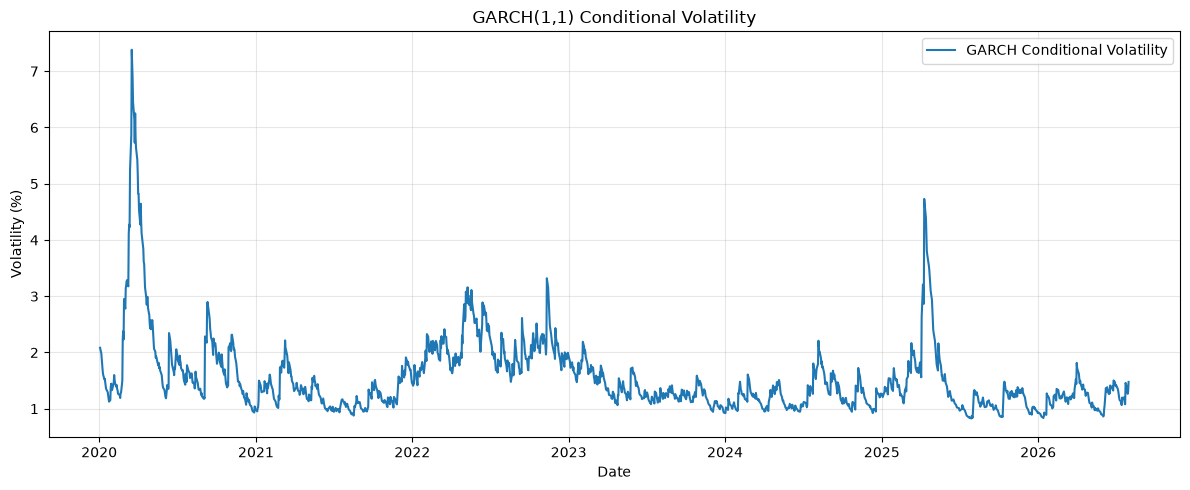

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(
    conditional_volatility * 100,
    label="GARCH Conditional Volatility"
)

plt.title("GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

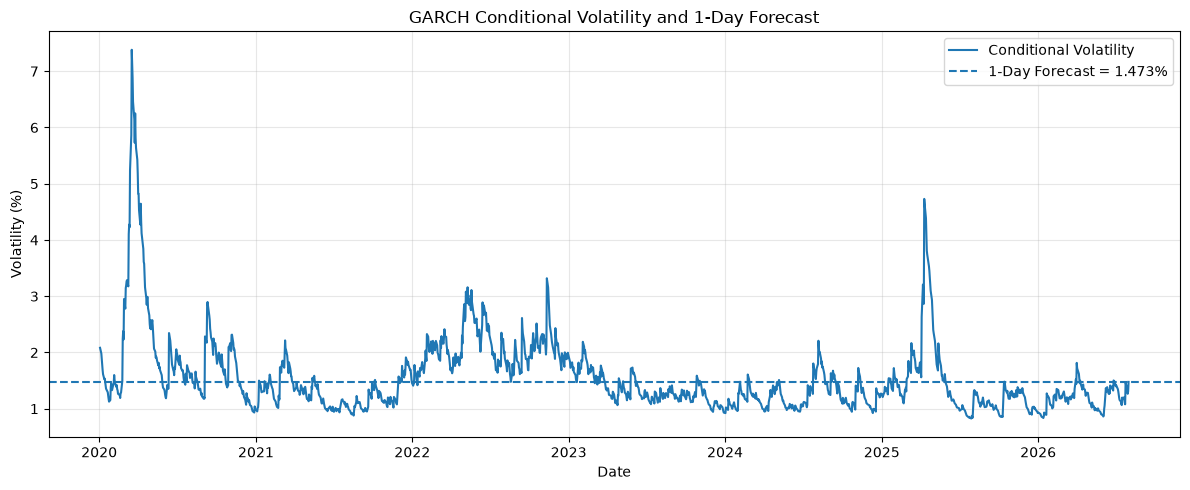

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    conditional_volatility * 100,
    label="Conditional Volatility"
)

plt.axhline(
    forecast_volatility * 100,
    linestyle="--",
    label=(
        f"1-Day Forecast = "
        f"{forecast_volatility * 100:.3f}%"
    )
)

plt.title(
    "GARCH Conditional Volatility "
    "and 1-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

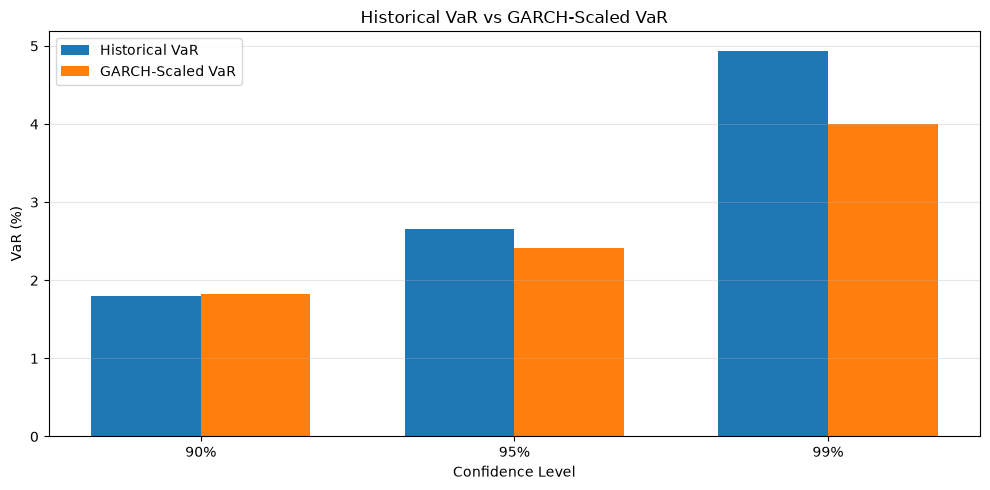

In [50]:
x = np.arange(3)

width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    [
        historical_var_90 * 100,
        historical_var_95 * 100,
        historical_var_99 * 100
    ],
    width,
    label="Historical VaR"
)

plt.bar(
    x + width / 2,
    [
        garch_var_90 * 100,
        garch_var_95 * 100,
        garch_var_99 * 100
    ],
    width,
    label="GARCH-Scaled VaR"
)

plt.xticks(
    x,
    ["90%", "95%", "99%"]
)

plt.xlabel("Confidence Level")
plt.ylabel("VaR (%)")

plt.title(
    "Historical VaR vs GARCH-Scaled VaR"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

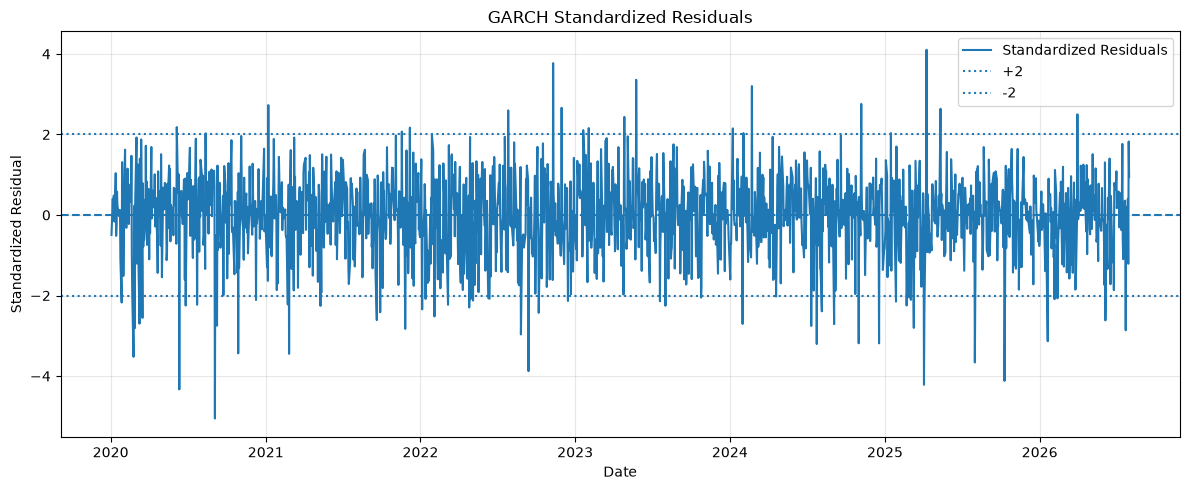

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(
    standardized_residuals,
    label="Standardized Residuals"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axhline(
    2,
    linestyle=":",
    label="+2"
)

plt.axhline(
    -2,
    linestyle=":",
    label="-2"
)

plt.title(
    "GARCH Standardized Residuals"
)

plt.xlabel("Date")
plt.ylabel("Standardized Residual")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

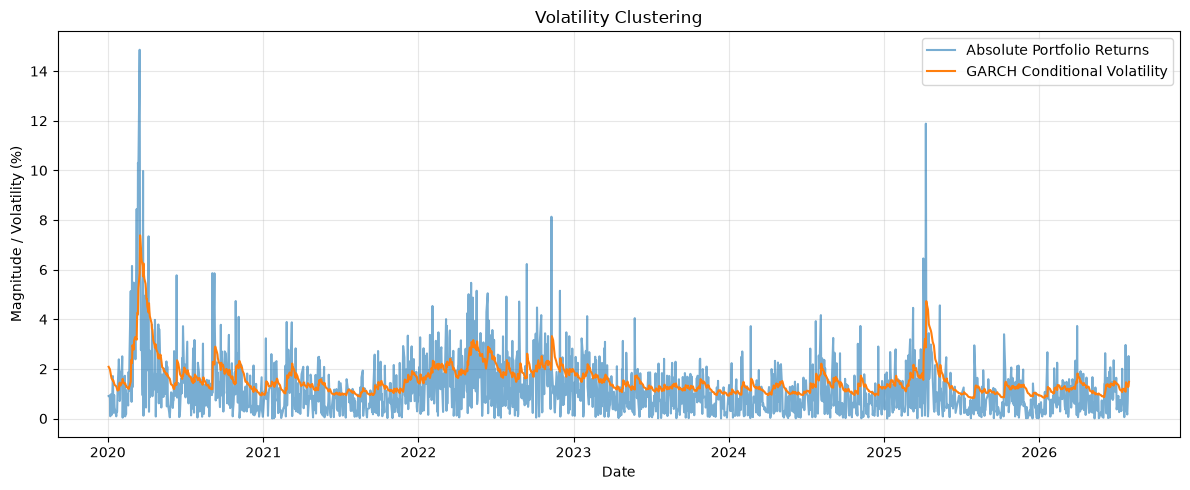

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    returns.abs() * 100,
    alpha=0.6,
    label="Absolute Portfolio Returns"
)

plt.plot(
    conditional_volatility * 100,
    label="GARCH Conditional Volatility"
)

plt.title(
    "Volatility Clustering"
)

plt.xlabel("Date")
plt.ylabel("Magnitude / Volatility (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()